In [1]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications.efficientnet import EfficientNetB3, preprocess_input

import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

c:\Users\KIIT0001\miniconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


TensorFlow version: 2.20.0
GPU available: []


In [2]:
# ============================================================
# OPTION A: LOCAL — Dataset is already on your machine
# (Just run this cell if using locally)
# ============================================================

DATA_DIR = r"C:\Users\KIIT0001\Downloads\Mini Project\IMFI Indian Medicinal Flower Image Dataset\IMFI Indian Medicinal Flower Image Dataset\IMFI Dataset"

if os.path.exists(DATA_DIR):
    print(f"✅ Dataset found at: {DATA_DIR}")
else:
    print(f"❌ Dataset not found at: {DATA_DIR}")
    print("Use Option B or C below if running on Google Colab.")

✅ Dataset found at: C:\Users\KIIT0001\Downloads\Mini Project\IMFI Indian Medicinal Flower Image Dataset\IMFI Indian Medicinal Flower Image Dataset\IMFI Dataset


In [ ]:
# ============================================================
# OPTION B: COLAB — Dataset ZIP is in Google Drive
# (Skip this cell if running locally)
# ============================================================

# from google.colab import drive
# import zipfile

# drive.mount('/content/drive')

# DRIVE_ZIP_PATH = "/content/drive/MyDrive/IMFI_Dataset.zip"  # <-- UPDATE THIS PATH
# EXTRACT_DIR = "/content/dataset"

# if os.path.exists(DRIVE_ZIP_PATH):
#     print(f"Extracting {DRIVE_ZIP_PATH}...")
#     os.makedirs(EXTRACT_DIR, exist_ok=True)
#     with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as z:
#         z.extractall(EXTRACT_DIR)
#     print("Done!")
# else:
#     print(f"ZIP not found at {DRIVE_ZIP_PATH}. Update the path above.")

In [ ]:
# ============================================================
# OPTION C: COLAB — Upload ZIP directly
# (Skip this cell if running locally)
# ============================================================

# from google.colab import files
# import zipfile

# print("Upload your dataset ZIP file:")
# uploaded = files.upload()

# EXTRACT_DIR = "/content/dataset"
# for fname in uploaded.keys():
#     print(f"Extracting {fname}...")
#     os.makedirs(EXTRACT_DIR, exist_ok=True)
#     with zipfile.ZipFile(fname, 'r') as z:
#         z.extractall(EXTRACT_DIR)
#     print("Done!")

In [ ]:
# ============================================================
# FOR COLAB ONLY: Auto-detect dataset root after extraction
# Uncomment the lines below if using Colab (Option B or C)
# ============================================================

# def find_dataset_root(base_dir):
#     for root, dirs, files_list in os.walk(base_dir):
#         if len(dirs) >= 10:
#             sample_dir = os.path.join(root, dirs[0])
#             if os.path.isdir(sample_dir):
#                 sample_files = os.listdir(sample_dir)
#                 img_files = [f for f in sample_files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
#                 if len(img_files) > 0:
#                     return root
#     return base_dir

# DATA_DIR = find_dataset_root(EXTRACT_DIR)
# print(f"Dataset root: {DATA_DIR}")

## 3. Load & Explore Dataset

In [3]:
def loading_the_data(data_dir):
    """Walk through subdirectories and build a DataFrame of file paths + labels."""
    filepaths = []
    labels = []

    folds = sorted(os.listdir(data_dir))
    for fold in folds:
        foldpath = os.path.join(data_dir, fold)
        if not os.path.isdir(foldpath):
            continue
        filelist = os.listdir(foldpath)
        for file in filelist:
            fpath = os.path.join(foldpath, file)
            if os.path.isfile(fpath):
                filepaths.append(fpath)
                labels.append(fold)

    Fseries = pd.Series(filepaths, name='filepaths')
    Lseries = pd.Series(labels, name='labels')
    df = pd.concat([Fseries, Lseries], axis=1)
    return df

# Load the data
df = loading_the_data(DATA_DIR)
print(f"Total images: {len(df)}")
print(f"Number of classes: {df['labels'].nunique()}")
df.head()

Total images: 6316
Number of classes: 28


,filepaths,labels
0,C:\Users\KIIT0001\Downloads\Mini Project\IMFI ...,Adathoda
1,C:\Users\KIIT0001\Downloads\Mini Project\IMFI ...,Adathoda
2,C:\Users\KIIT0001\Downloads\Mini Project\IMFI ...,Adathoda
3,C:\Users\KIIT0001\Downloads\Mini Project\IMFI ...,Adathoda
4,C:\Users\KIIT0001\Downloads\Mini Project\IMFI ...,Adathoda


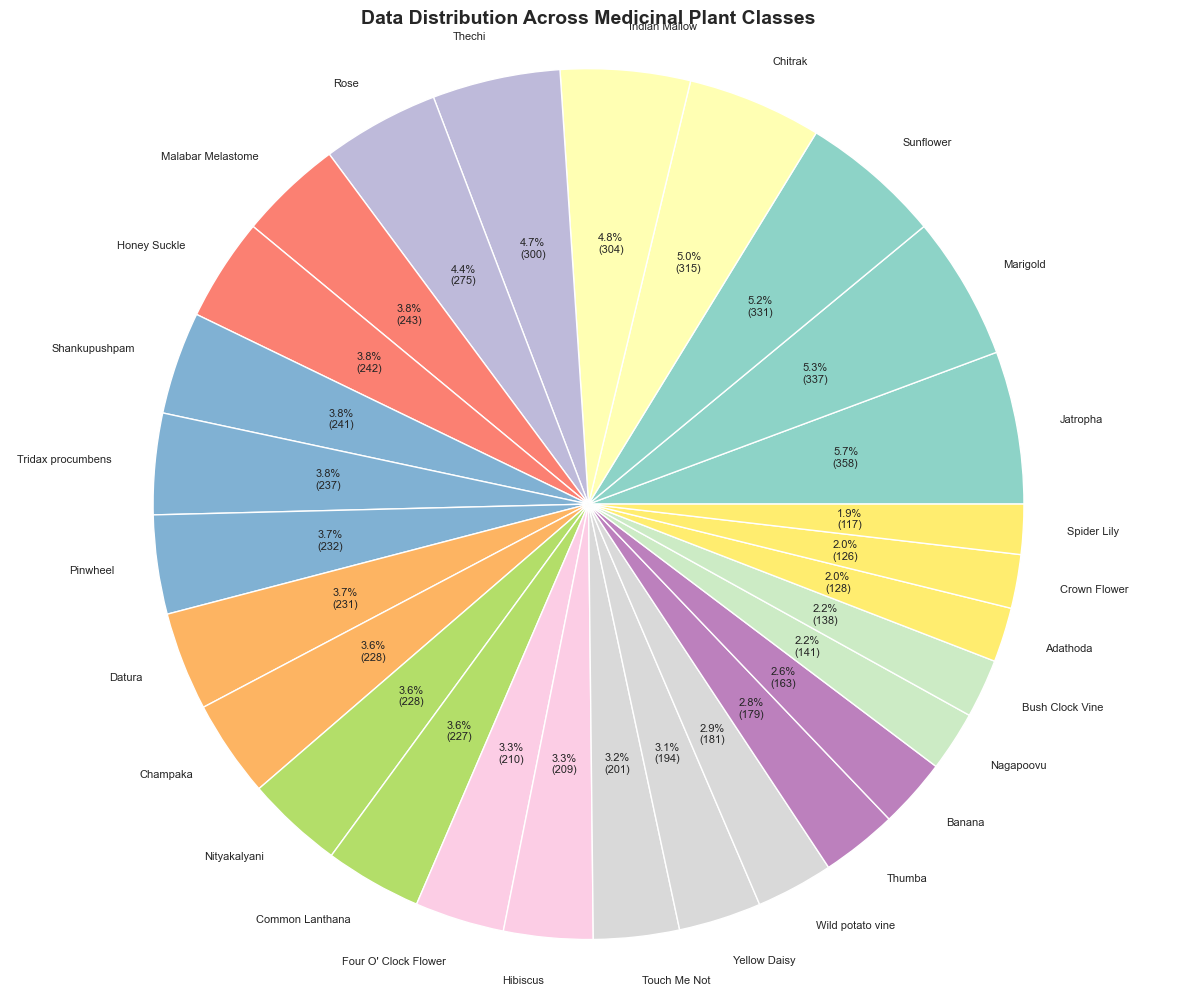

In [4]:
# Data distribution - Pie chart
data_balance = df.labels.value_counts()

def custom_autopct(pct):
    total = sum(data_balance)
    val = int(round(pct * total / 100.0))
    return "{:.1f}%\n({:d})".format(pct, val)

plt.figure(figsize=(12, 10))
colors = plt.cm.Set3(np.linspace(0, 1, len(data_balance)))
plt.pie(data_balance, labels=data_balance.index, autopct=custom_autopct, colors=colors, textprops={'fontsize': 8})
plt.title("Data Distribution Across Medicinal Plant Classes", fontsize=14, fontweight='bold')
plt.axis("equal")
plt.tight_layout()
plt.show()

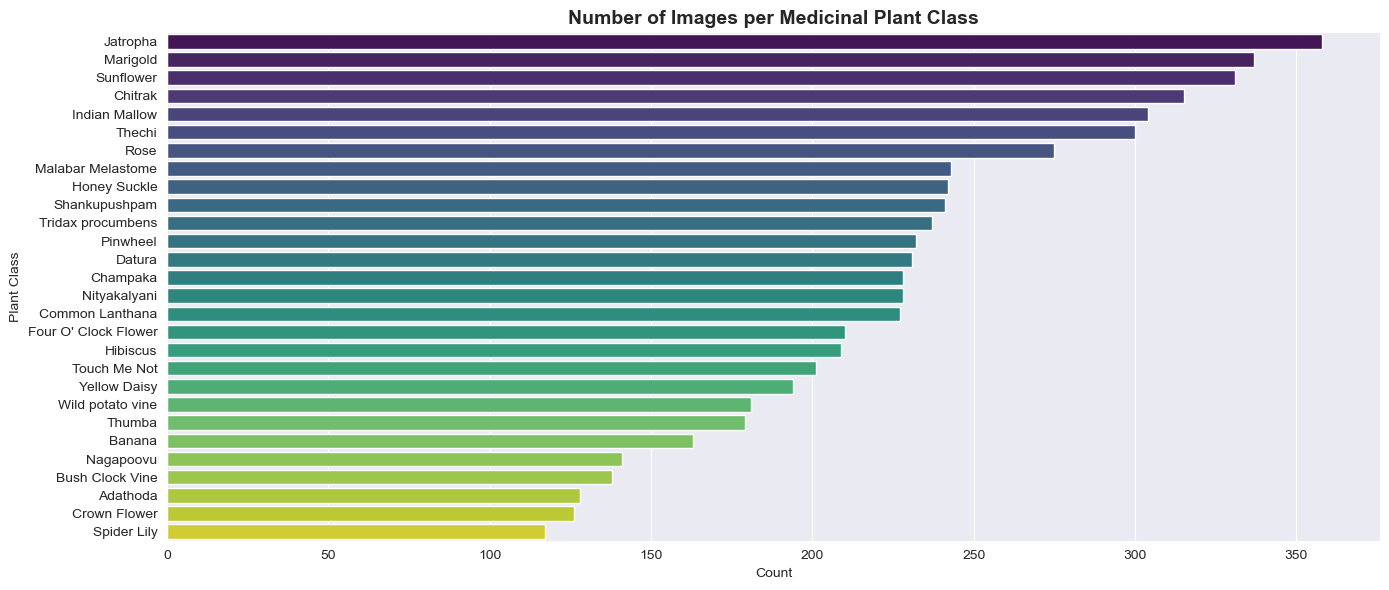

In [5]:
# Bar chart for better visibility
plt.figure(figsize=(14, 6))
ax = sns.countplot(data=df, y='labels', order=df['labels'].value_counts().index, palette='viridis')
plt.title('Number of Images per Medicinal Plant Class', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Plant Class')
plt.tight_layout()
plt.show()

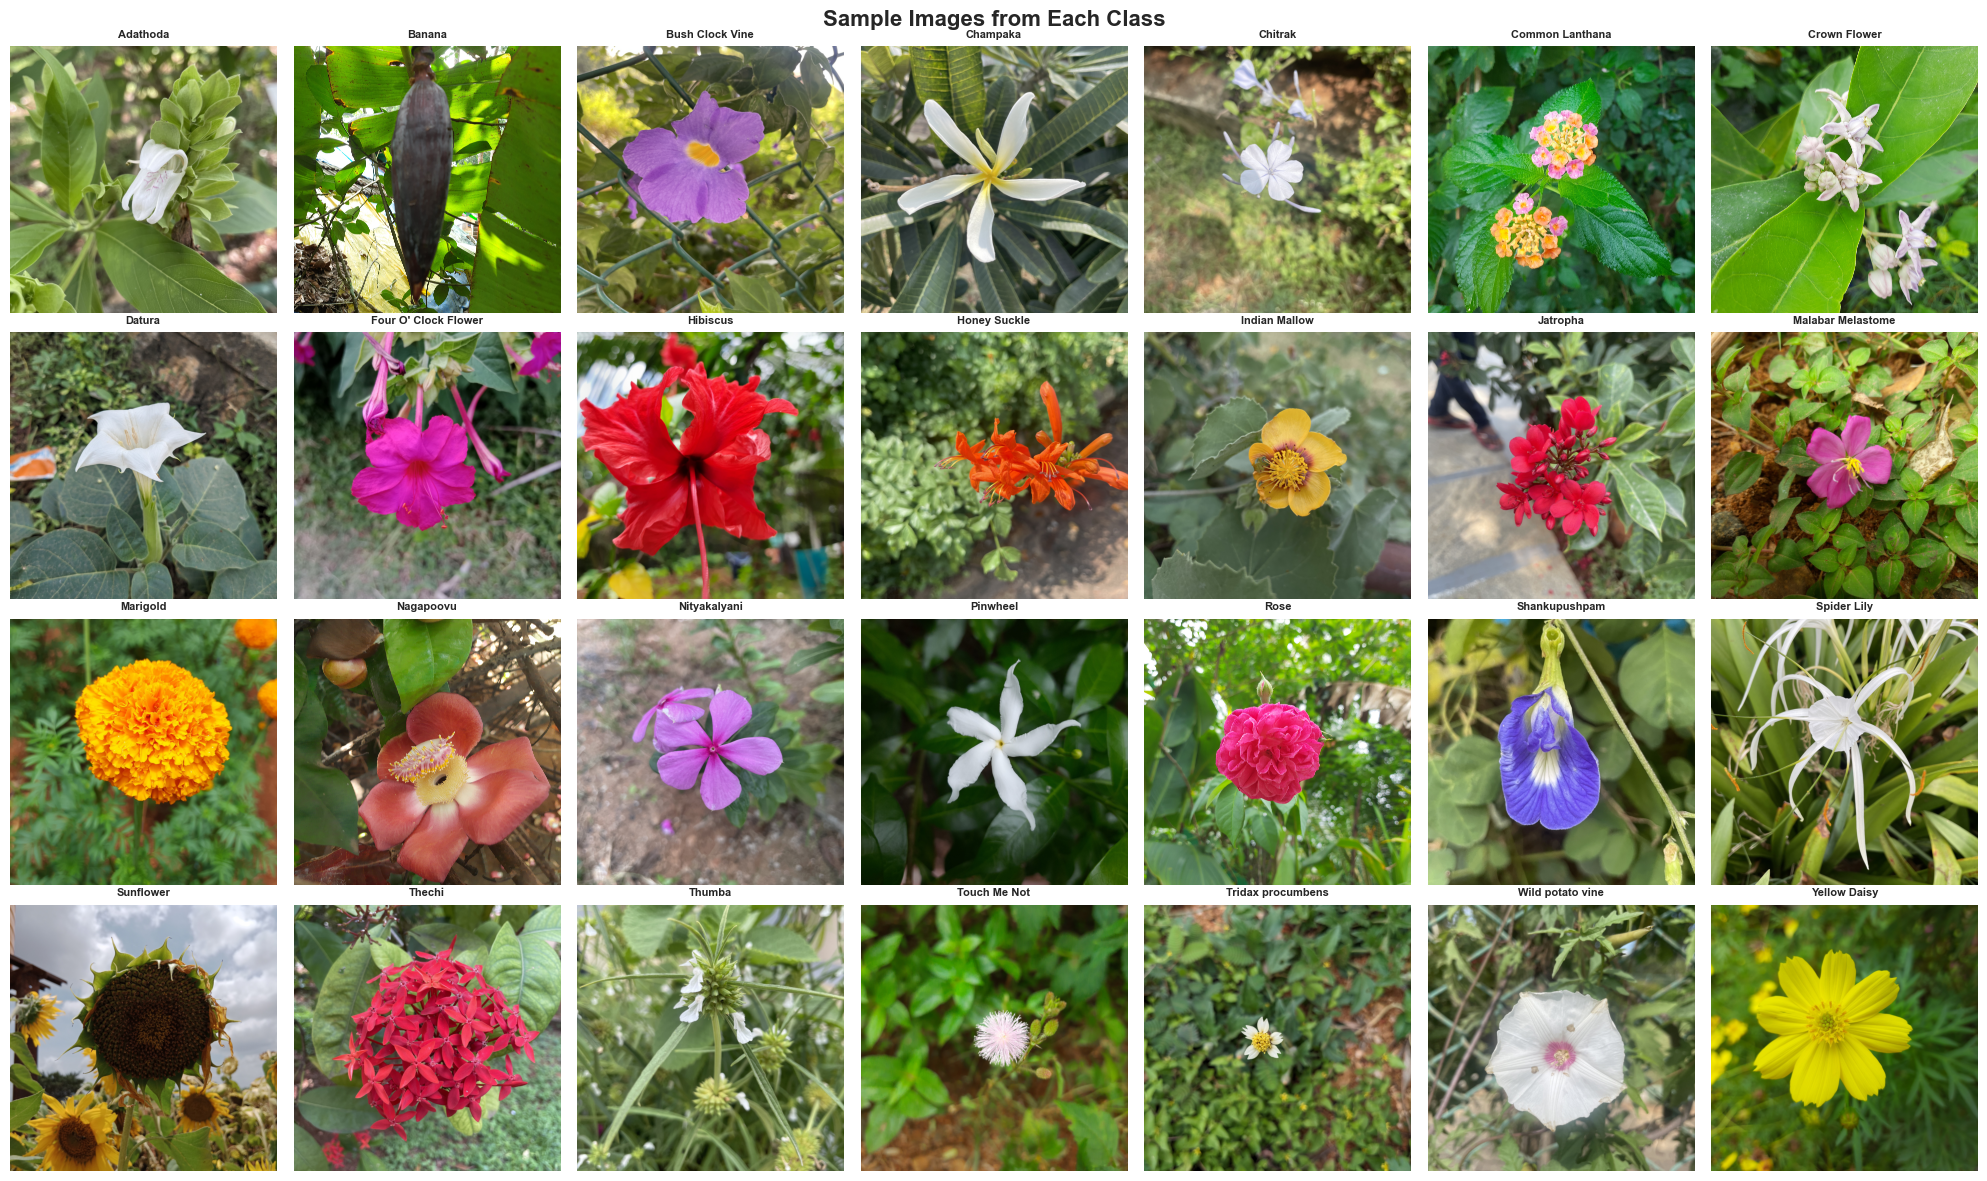

In [6]:
# Show sample images from each class
fig, axes = plt.subplots(4, 7, figsize=(20, 12))
fig.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold')

classes = sorted(df['labels'].unique())
for idx, (ax, class_name) in enumerate(zip(axes.flatten(), classes)):
    class_df = df[df['labels'] == class_name]
    sample_path = class_df.iloc[0]['filepaths']
    img = plt.imread(sample_path)
    ax.imshow(img)
    ax.set_title(class_name, fontsize=8, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Train / Validation / Test Split

In [7]:
# 80% train, 10% validation, 10% test (stratified)
train_df, ts_df = train_test_split(df, train_size=0.8, shuffle=True, random_state=42, stratify=df['labels'])
valid_df, test_df = train_test_split(ts_df, train_size=0.5, shuffle=True, random_state=42, stratify=ts_df['labels'])

print(f"Train: {len(train_df)} images")
print(f"Validation: {len(valid_df)} images")
print(f"Test: {len(test_df)} images")

Train: 5052 images
Validation: 632 images
Test: 632 images


## 5. Data Generators (with Augmentation)

In [8]:
batch_size = 16
img_size = (224, 224)

# Training data: augmented
tr_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation/Test data: no augmentation
ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = tr_gen.flow_from_dataframe(
    train_df, x_col='filepaths', y_col='labels',
    target_size=img_size, class_mode='categorical',
    color_mode='rgb', shuffle=True, batch_size=batch_size
)

valid_gen = ts_gen.flow_from_dataframe(
    valid_df, x_col='filepaths', y_col='labels',
    target_size=img_size, class_mode='categorical',
    color_mode='rgb', shuffle=True, batch_size=batch_size
)

test_gen = ts_gen.flow_from_dataframe(
    test_df, x_col='filepaths', y_col='labels',
    target_size=img_size, class_mode='categorical',
    color_mode='rgb', shuffle=False, batch_size=batch_size
)

# Save class indices for inference later
class_indices = train_gen.class_indices
with open('medicinal_class_indices.json', 'w') as f:
    json.dump(class_indices, f, indent=2)

num_classes = len(class_indices)
print(f"\nNumber of classes: {num_classes}")
print(f"Class indices saved to: medicinal_class_indices.json")
print(f"\nClass mapping:")
for name, idx in sorted(class_indices.items(), key=lambda x: x[1]):
    print(f"  {idx:2d}: {name}")

Found 5052 validated image filenames belonging to 28 classes.
Found 632 validated image filenames belonging to 28 classes.
Found 632 validated image filenames belonging to 28 classes.

Number of classes: 28
Class indices saved to: medicinal_class_indices.json

Class mapping:
   0: Adathoda
   1: Banana
   2: Bush Clock Vine
   3: Champaka
   4: Chitrak
   5: Common Lanthana
   6: Crown Flower
   7: Datura
   8: Four O' Clock Flower
   9: Hibiscus
  10: Honey Suckle
  11: Indian Mallow
  12: Jatropha
  13: Malabar Melastome
  14: Marigold
  15: Nagapoovu
  16: Nityakalyani
  17: Pinwheel
  18: Rose
  19: Shankupushpam
  20: Spider Lily
  21: Sunflower
  22: Thechi
  23: Thumba
  24: Touch Me Not
  25: Tridax procumbens
  26: Wild potato vine
  27: Yellow Daisy


## 6. Build the EfficientNetB3 Model

In [9]:
def dense_block(dense, units, dropout_rate, act='relu'):
    """Helper to build dense -> batchnorm -> dropout blocks."""
    x = Dense(units, activation=act)(dense)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    return x

# EfficientNetB3 base (pre-trained on ImageNet)
img_shape = (224, 224, 3)
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=img_shape, pooling=None)

# Freeze base model for Phase 1
base_model.trainable = False

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = dense_block(x, 256, 0.5)
x = dense_block(x, 128, 0.3)
x = dense_block(x, 64, 0.2)

predictions = Dense(num_classes, activation='softmax')(x)

EfficientNetB3_model = Model(inputs=base_model.input, outputs=predictions)

EfficientNetB3_model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Total parameters: {EfficientNetB3_model.count_params():,}")
trainable = sum([tf.keras.backend.count_params(w) for w in EfficientNetB3_model.trainable_weights])
print(f"Trainable parameters: {trainable:,}")
print(f"Non-trainable parameters: {EfficientNetB3_model.count_params() - trainable:,}")

Total parameters: 11,227,915
Trainable parameters: 440,412
Non-trainable parameters: 10,787,503


## 7. Phase 1 — Train Classification Head (Base Frozen)

In [10]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('medicinal_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

INITIAL_EPOCHS = 30

print(f"Phase 1: Training classification head ({INITIAL_EPOCHS} epochs)...")
print("Base model layers: FROZEN\n")

history1 = EfficientNetB3_model.fit(
    train_gen,
    epochs=INITIAL_EPOCHS,
    validation_data=valid_gen,
    callbacks=callbacks,
    verbose=1
)

Phase 1: Training classification head (10 epochs)...
Base model layers: FROZEN

Epoch 1/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0415 - loss: 3.9774
Epoch 1: val_accuracy improved from None to 0.05222, saving model to medicinal_model.keras

Epoch 1: finished saving model to medicinal_model.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 1203s 4s/step - accuracy: 0.0416 - loss: 3.8895 - val_accuracy: 0.0522 - val_loss: 3.3710 - learning_rate: 0.0010
Epoch 2/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.0531 - loss: 3.6783
Epoch 2: val_accuracy improved from 0.05222 to 0.07753, saving model to medicinal_model.keras

Epoch 2: finished saving model to medicinal_model.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 1386s 4s/step - accuracy: 0.0519 - loss: 3.6438 - val_accuracy: 0.0775 - val_loss: 3.2375 - learning_rate: 0.0010
Epoch 3/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 80s/step - accuracy: 0.0563 - loss: 3.5678  
Epoch 3: val_accuracy improved from 0.07753 to 0.09019, saving model to medic

## 8. Phase 2 — Fine-tune Top Layers

In [11]:
# Unfreeze the last 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate
EfficientNetB3_model.compile(
    optimizer=Adamax(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable = sum([tf.keras.backend.count_params(w) for w in EfficientNetB3_model.trainable_weights])
print(f"Trainable parameters after unfreezing: {trainable:,}")

FINE_TUNE_EPOCHS = 20

print(f"\nPhase 2: Fine-tuning top layers ({FINE_TUNE_EPOCHS} epochs)...\n")

history2 = EfficientNetB3_model.fit(
    train_gen,
    epochs=FINE_TUNE_EPOCHS,
    validation_data=valid_gen,
    callbacks=callbacks,
    verbose=1
)

Trainable parameters after unfreezing: 3,994,582

Phase 2: Fine-tuning top layers (10 epochs)...

Epoch 1/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.0518 - loss: 3.3670
Epoch 1: val_accuracy did not improve from 0.10601
316/316 ━━━━━━━━━━━━━━━━━━━━ 1659s 5s/step - accuracy: 0.0550 - loss: 3.3552 - val_accuracy: 0.0633 - val_loss: 3.2603 - learning_rate: 1.0000e-04
Epoch 2/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.0575 - loss: 3.3211
Epoch 2: val_accuracy did not improve from 0.10601
316/316 ━━━━━━━━━━━━━━━━━━━━ 1653s 5s/step - accuracy: 0.0598 - loss: 3.3237 - val_accuracy: 0.0728 - val_loss: 3.1802 - learning_rate: 1.0000e-04
Epoch 3/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.0637 - loss: 3.3218
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 3: val_accuracy did not improve from 0.10601
316/316 ━━━━━━━━━━━━━━━━━━━━ 1500s 5s/step - accuracy: 0.0673 - loss: 3.3278 - val_accuracy: 0.0949 - val_loss: 3.1647 - le

## 9. Evaluate on Test Set

In [12]:
print("Evaluating on test set...\n")
test_loss, test_accuracy = EfficientNetB3_model.evaluate(test_gen, verbose=1)

print(f"\n{'='*50}")
print(f"  TEST ACCURACY: {test_accuracy:.2%}")
print(f"  TEST LOSS:     {test_loss:.4f}")
print(f"{'='*50}")

Evaluating on test set...

40/40 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.0744 - loss: 3.2579

  TEST ACCURACY: 7.44%
  TEST LOSS:     3.2579


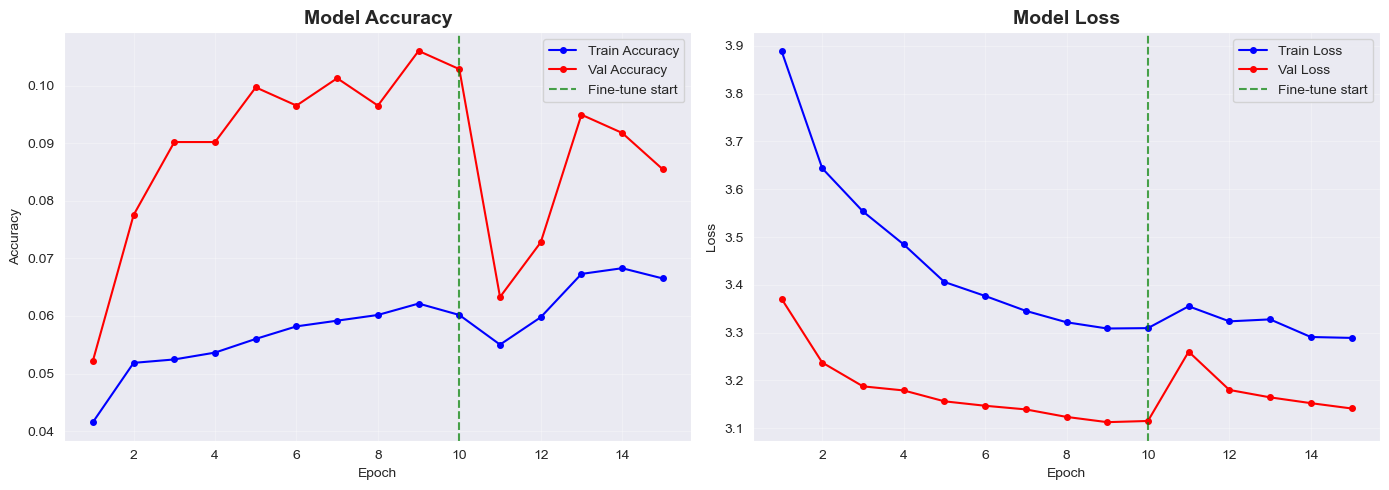

In [13]:
# Training history plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']
epochs_range = range(1, len(acc) + 1)

ax1.plot(epochs_range, acc, 'b-o', label='Train Accuracy', markersize=4)
ax1.plot(epochs_range, val_acc, 'r-o', label='Val Accuracy', markersize=4)
ax1.axvline(x=len(history1.history['accuracy']), color='green', linestyle='--', alpha=0.7, label='Fine-tune start')
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, loss, 'b-o', label='Train Loss', markersize=4)
ax2.plot(epochs_range, val_loss, 'r-o', label='Val Loss', markersize=4)
ax2.axvline(x=len(history1.history['loss']), color='green', linestyle='--', alpha=0.7, label='Fine-tune start')
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

In [14]:
# Confusion matrix
test_gen.reset()
predictions = EfficientNetB3_model.predict(test_gen, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes

labels_map = {v: k for k, v in class_indices.items()}
class_names = [labels_map[i] for i in range(num_classes)]

print("\nClassification Report:")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

40/40 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step

Classification Report:
                      precision    recall  f1-score   support

            Adathoda       0.00      0.00      0.00        13
              Banana       0.00      0.00      0.00        16
     Bush Clock Vine       0.00      0.00      0.00        14
            Champaka       0.00      0.00      0.00        23
             Chitrak       0.00      0.00      0.00        31
     Common Lanthana       0.00      0.00      0.00        23
        Crown Flower       0.00      0.00      0.00        13
              Datura       0.00      0.00      0.00        23
Four O' Clock Flower       0.00      0.00      0.00        21
            Hibiscus       0.00      0.00      0.00        21
        Honey Suckle       0.00      0.00      0.00        24
       Indian Mallow       0.00      0.00      0.00        31
            Jatropha       0.00      0.00      0.00        36
   Malabar Melastome       0.00      0.00      0.00        24
      

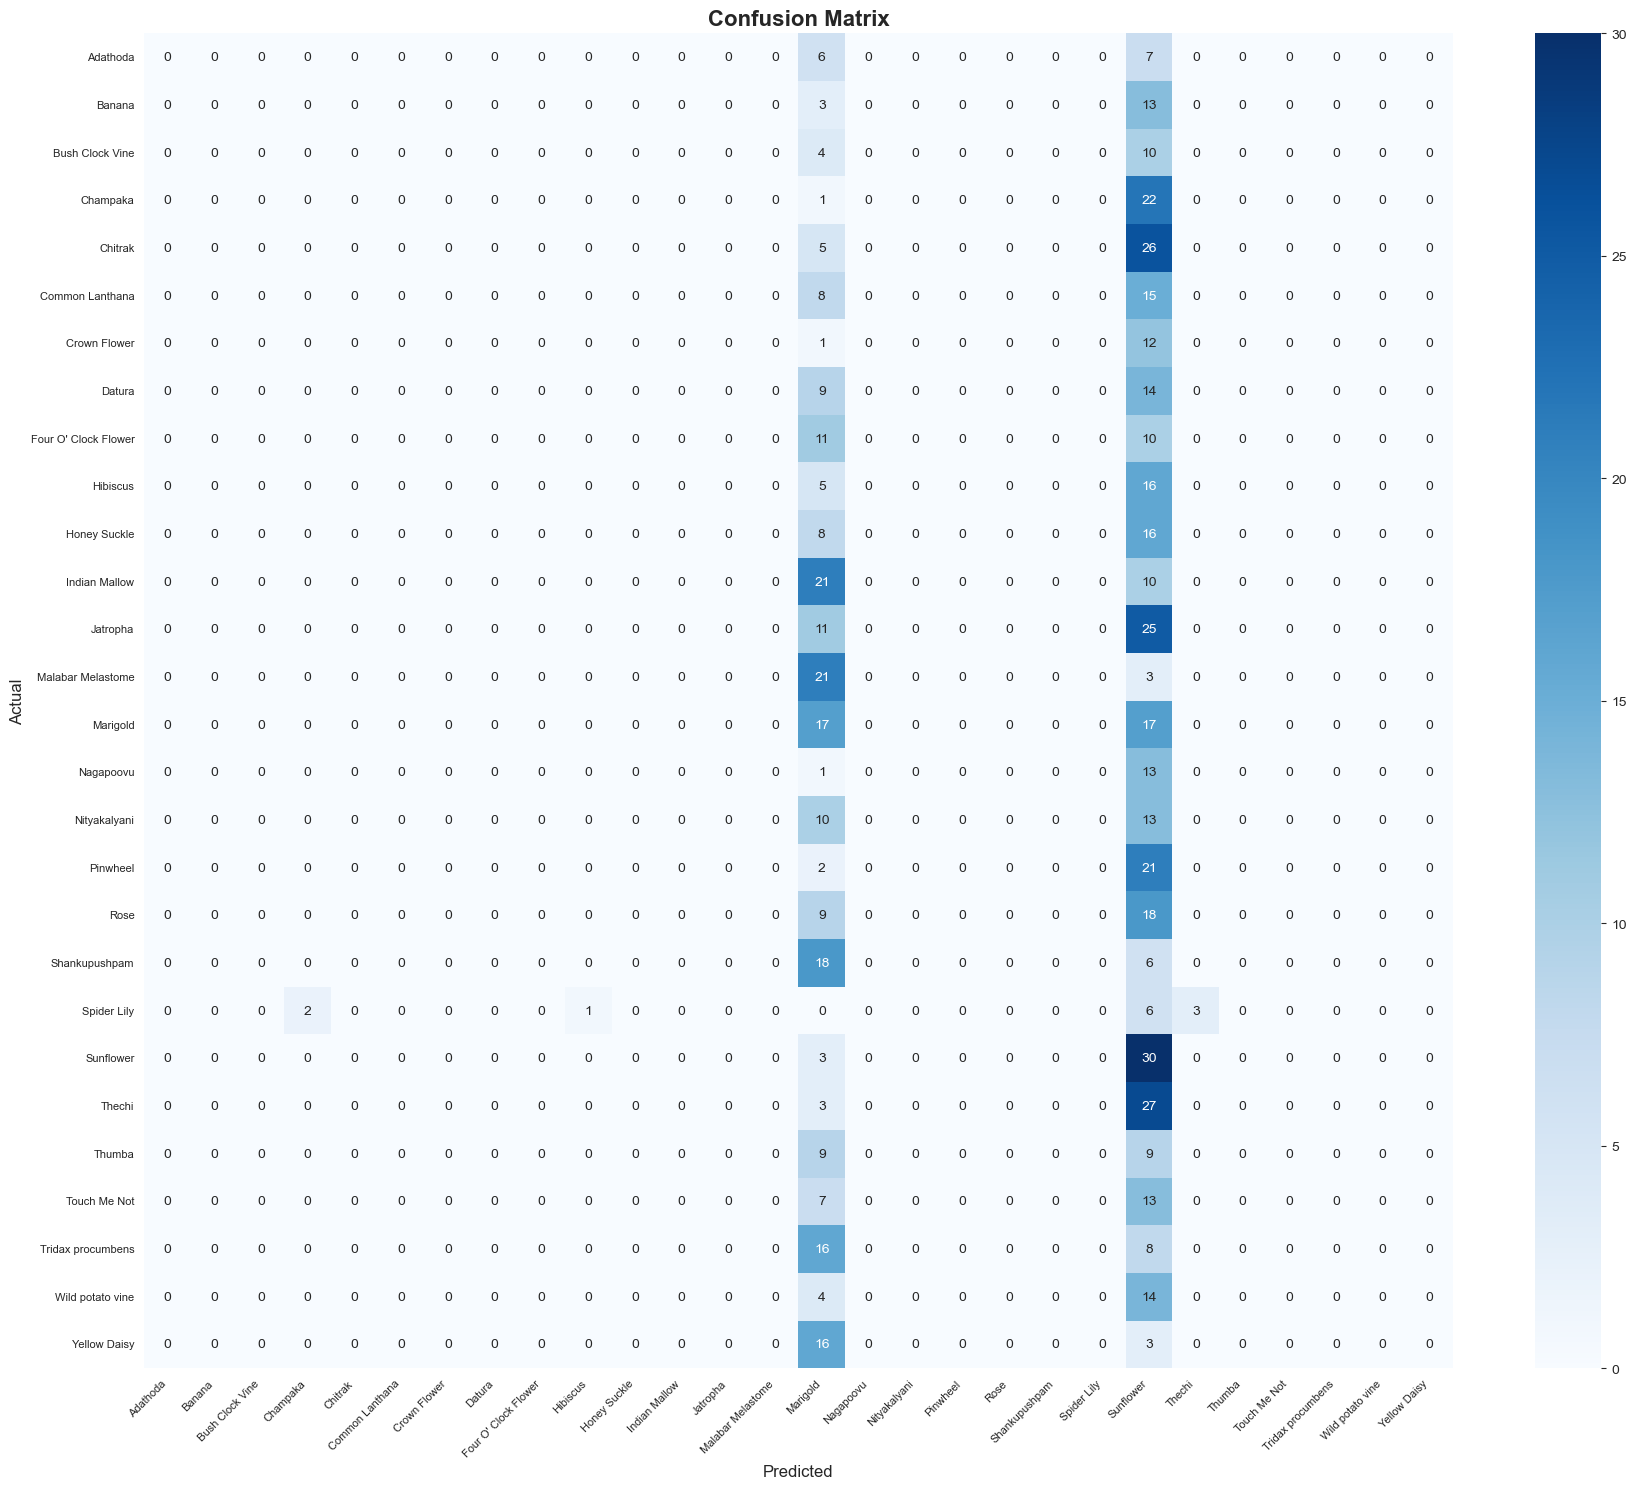

In [15]:
# Confusion matrix heatmap
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 10. Save Model

In [16]:
# Save the final model
EfficientNetB3_model.save('medicinal_model.keras')

print("✅ Model saved: medicinal_model.keras")
print(f"   Model size: {os.path.getsize('medicinal_model.keras') / (1024*1024):.1f} MB")
print("✅ Class indices saved: medicinal_class_indices.json")
print(f"\nYou can now run: python test_model.py")

✅ Model saved: medicinal_model.keras
   Model size: 74.7 MB
✅ Class indices saved: medicinal_class_indices.json

You can now run: python test_model.py


## 11. Quick Test — Predict & Show Medicinal Properties

In [19]:
# Load medicinal properties
with open('medicinal_properties.json', 'r') as f:
    medicinal_properties = json.load(f)

# Invert class indices for prediction
labels = {v: k for k, v in class_indices.items()}

def predict_and_show(image_path):
    """Predict the plant and display its medicinal properties."""
    from tensorflow.keras.preprocessing import image as keras_image
    
    img = keras_image.load_img(image_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)
    from tensorflow.keras.applications.efficientnet import preprocess_input
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    preds = EfficientNetB3_model.predict(img_array, verbose=0)
    top3 = np.argsort(preds[0])[::-1][:3]

    predicted_name = labels[top3[0]]
    confidence = preds[0][top3[0]]

    # Show image
    plt.figure(figsize=(6, 6))
    plt.imshow(keras_image.load_img(image_path))
    plt.title(f"{predicted_name} ({confidence:.1%})", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

    # Show top-3 predictions
    print(f"\n{'='*50}")
    print(f"  TOP-3 PREDICTIONS")
    print(f"{'='*50}")
    for rank, idx in enumerate(top3, 1):
        name = labels[idx]
        conf = preds[0][idx]
        bar = '█' * int(conf * 30)
        print(f"  {rank}. {name:30s} {conf:6.2%}  {bar}")

    # Show medicinal properties
    props = medicinal_properties.get(predicted_name)
    if props:
        print(f"\n{'='*50}")
        print(f"  MEDICINAL PROPERTIES")
        print(f"{'='*50}")
        print(f"  Scientific Name : {props['scientific_name']}")
        print(f"  Family          : {props['family']}")
        print(f"  Common Names    : {', '.join(props['common_names'])}")
        print(f"  Parts Used      : {', '.join(props['parts_used'])}")
        print(f"\n  Medicinal Uses:")
        for use in props['medicinal_uses']:
            print(f"    • {use}")
        print(f"\n  Key Compounds   : {', '.join(props['key_compounds'])}")
        print(f"  Traditional Systems: {', '.join(props['traditional_systems'])}")
        print(f"\n  ⚠ Precautions: {props['precautions']}")
    
    print(f"\n{'='*50}")
    print("  DISCLAIMER: For educational purposes only.")
    print(f"{'='*50}")

print("Function ready! Use:  predict_and_show('path/to/image.jpg')")

Function ready! Use:  predict_and_show('path/to/image.jpg')


Testing with: Datura


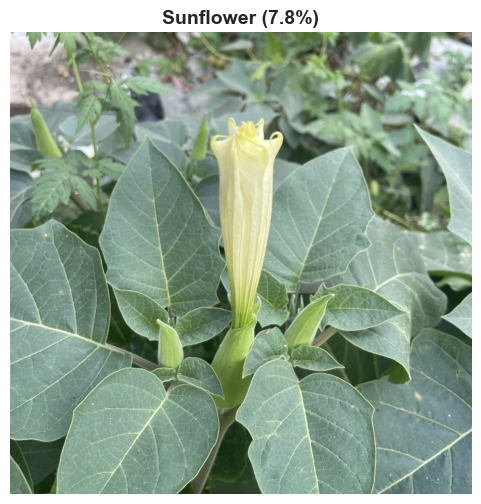


  TOP-3 PREDICTIONS
  1. Sunflower                       7.78%  ██
  2. Thechi                          7.26%  ██
  3. Datura                          5.54%  █

  MEDICINAL PROPERTIES
  Scientific Name : Helianthus annuus
  Family          : Asteraceae
  Common Names    : Sunflower, Surajmukhi
  Parts Used      : Seeds, Flowers, Leaves, Root

  Medicinal Uses:
    • Seeds are rich in Vitamin E — antioxidant and skin health
    • Sunflower oil used for lowering cholesterol
    • Leaf tea used as astringent and diuretic
    • Used for treating bronchial and throat infections
    • Anti-inflammatory properties

  Key Compounds   : Vitamin E, Linoleic acid, Heliannone, Lecithin
  Traditional Systems: Folk medicine, Native American medicine

  ⚠ Precautions: Generally safe. Seed allergy possible in rare cases. High calorie — moderate consumption advised.

  DISCLAIMER: For educational purposes only.


In [20]:
# ============================================================
# TEST: Enter your image path here to test the model
# ============================================================

# Example: pick a random test image
sample = test_df.sample(1).iloc[0]
print(f"Testing with: {sample['labels']}")
predict_and_show(sample['filepaths'])

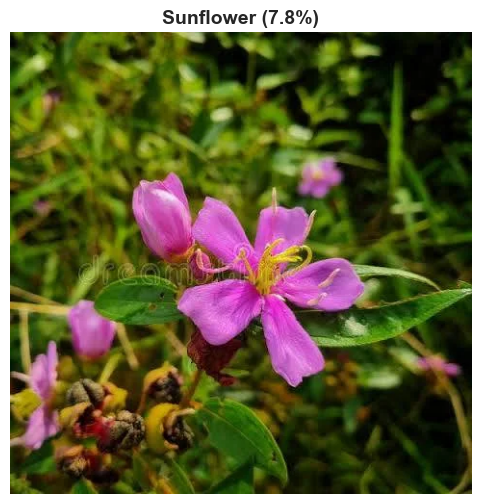


  TOP-3 PREDICTIONS
  1. Sunflower                       7.81%  ██
  2. Thechi                          7.22%  ██
  3. Datura                          5.50%  █

  MEDICINAL PROPERTIES
  Scientific Name : Helianthus annuus
  Family          : Asteraceae
  Common Names    : Sunflower, Surajmukhi
  Parts Used      : Seeds, Flowers, Leaves, Root

  Medicinal Uses:
    • Seeds are rich in Vitamin E — antioxidant and skin health
    • Sunflower oil used for lowering cholesterol
    • Leaf tea used as astringent and diuretic
    • Used for treating bronchial and throat infections
    • Anti-inflammatory properties

  Key Compounds   : Vitamin E, Linoleic acid, Heliannone, Lecithin
  Traditional Systems: Folk medicine, Native American medicine

  ⚠ Precautions: Generally safe. Seed allergy possible in rare cases. High calorie — moderate consumption advised.

  DISCLAIMER: For educational purposes only.


In [29]:
# ============================================================
# TEST WITH YOUR OWN IMAGE
# ============================================================

 # Uncomment and update the path below:
predict_and_show(r"C:\Users\KIIT0001\Downloads\test1.webp")